## PtyChee Analytical Ptychogrpahy Demo

Running WDD and SSB ptychogrpahy

Author: Zeyu Wang <br>
October 2025

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PtyChee import run

4D-STEM data and parameters read in, this data uesd a total dose of only ~36 e<sup>-</sup>/Å<sup>2</sup>.

In [13]:
file_read = 'data/'
file = 'MAPbI3_HT200_a13_ss0.3_31_F3sum.npy'
data_4D = np.load(file_read+file)
print(data_4D.shape)

Voltage = 200               #keV, accelerate votage
alpha = 0.013               #rad, semi convergence angle
scan_step = 0.3             #Å,   scan step size

defocus = -60               #Å,   defocus

(800, 800, 38, 38)


This dataset was acquired with a total dose of only ~36 e<sup>-</sup>/Å<sup>2</sup>. By plotting a single CBED pattern, we can see just how sparse the signal is.

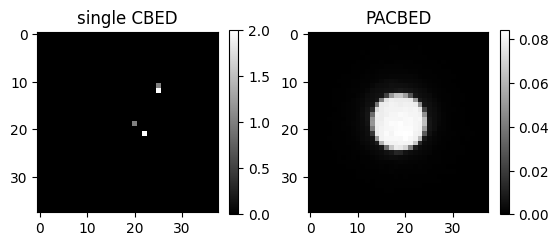

In [14]:
plt.subplot(121)
plt.imshow(data_4D[400,400], cmap='gray')
plt.title('single CBED')
plt.colorbar(shrink=0.5)
plt.subplot(122)
plt.imshow(np.mean(data_4D,axis=(0,1)), cmap='gray')
plt.title('PACBED')
plt.colorbar(shrink=0.5)
plt.show()

You can use PtyChee.finRotate to calculate the optimized scan rotate angle, <br>
see 'run_ptyChee_01_findRotate_and_iCoM_MAPbI3_F3sum.ipynb'

In [15]:
scan_rotation_angle = -176   #degrees
scan_flip = False            #flip X axis or not

Crop the CBEDs slightly to reduce memory usage. Make sure not to crop out the bright-field information; ideally, retain information up to 2α.

In [16]:
data_4D = data_4D[:,:,7:-7,7:-7]

Run WDD ptychography


WDD
File: MAPbI3_HT200_a13_ss0.3_31_F3sum.npy

################ Experimental Information ################
Voltage: 200 kV
Alpha: 0.013 rad
scan step: 0.3 Å/pixel
defocus: -60 Å
scan rotation angle: -176 degrees
scan flip x: False

#################### Data Information ####################
data shape: (800, 800, 24, 24)
data type: int8
CBED intensity range: 0 – 14
average CBED intensity: 9.506206512451172
BF center_Y: 11.581818181818182
BF center_X: 11.663636363636364
BF threshold: 0.5
Aperture Radius: 5.843108646253187 pixels

################ Calculatied Calibration #################
reciprocal space pixel size: 0.08871216110464294 1/Å/pixel

##################### WDD Parameters ######################
Trotter Pattern rotation angle: 176 degrees
Trotter Pattern flip x: False
WDD epsilon: 0.1

####################### WDD Process #######################
fft along p finished in 2.025324821472168 s
ifft along rPrime finished in 0.9224157333374023 s
ApeFunc_WDD progressing: 100%[*********-

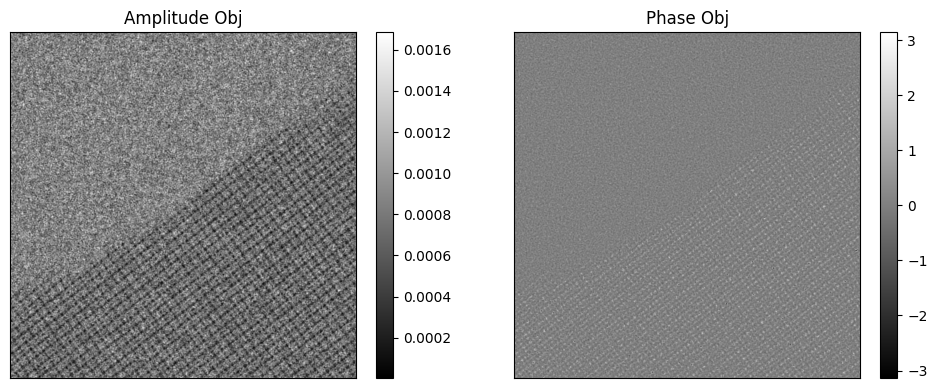

In [17]:
# WDD
run.run_WDD(file, data_4D, Voltage, alpha, scan_step, scan_rotation_angle, scan_flip, 
        defocus,
        #epsilon_WDD = 0.1,             # epsilon for calculating WDD
        save_results = False,
)

Run SSB ptychogrpahy


SSB
File: MAPbI3_HT200_a13_ss0.3_31_F3sum.npy

################ Experimental Information ################
Voltage: 200 kV
Alpha: 0.013 rad
scan step: 0.3 Å/pixel
scan rotation angle: -176 degrees
scan flip x: False

#################### Data Information ####################
data shape: (800, 800, 24, 24)
data type: int8
CBED intensity range: 0 – 14
average CBED intensity: 9.506206512451172
BF center_Y: 11.581818181818182
BF center_X: 11.663636363636364
BF threshold: 0.5
Aperture Radius: 5.843108646253187 pixels

################ Calculatied Calibration #################
reciprocal space pixel size: 0.08871216110464294 1/Å/pixel

###################### SSB Parameters #####################
Trotter Pattern rotation angle: 176 degrees
Trotter Pattern flip x: False

####################### SSB Process #######################
fft along p finished in 2.0275495052337646 s
SSB progressing: 100%[*********->.] 21.88iter/s (00:00:40<00:00:00)
SSB process finished in 40.104602575302124 s

########

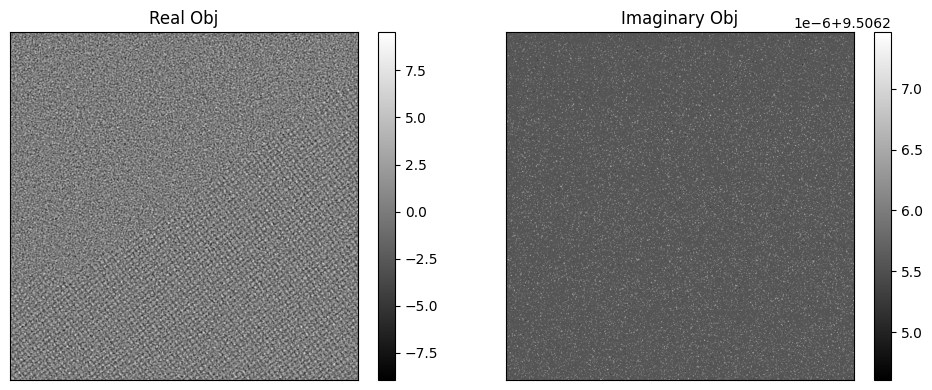

In [18]:
# SSB
run.run_SSB(file, data_4D, Voltage, alpha, scan_step, scan_rotation_angle, scan_flip,
        save_results = False,
)